# LeetCode #1: Two Sum

https://leetcode.com/problems/two-sum/

## Comparison of Approaches

| Approach | Time Complexity | Space Complexity |
| :--- | :--- | :--- |
| **Brute Force** | $O(n^2)$ | $O(1)$ |
| **Two-Pass Hash Map** | $O(n)$ | $O(n)$ |
| **One-Pass Hash Map** | $O(n)$ | $O(n)$ |

---

## Understanding the Methods

### Brute Force
Use two nested loops to check every pair. The outer loop picks element `i`, the inner loop checks every element `j` after it. If `nums[i] + nums[j] == target`, return their indices. Simple but slow — $O(n^2)$ time.

### Two-Pass Hash Map
First pass: store every number and its index in a hash map. Second pass: for each number, check if its complement (`target - nums[i]`) exists in the map. Same $O(n)$ time as one-pass, but iterates the array twice.

### Optimal: One-Pass Hash Map ★
Combine both steps into a single loop. For each number, check if its complement is already in the map — if yes, return immediately. If not, add the current number to the map. Finds the answer in one pass, often returning before scanning the full array.

**Why this is better than two-pass:** Both are $O(n)$, but one-pass can short-circuit on the first match. Two-pass always builds the entire map first, even if the answer is at indices 0 and 1.

**Constraints:**
* Each input has exactly one solution.
* You may not use the same element twice.

## Solutions

### C#

In [ ]:
using System;
using System.Collections.Generic; 

public class Solution {
    public int[] TwoSum(int[] nums, int target) {
        // Create a dictionary to store: Key = number value, Value = index
        Dictionary<int, int> seenNumbers = new Dictionary<int, int>();

        for (int i = 0; i < nums.Length; i++) {
            // Calculate the complement needed to hit the target
            int complement = target - nums[i];

            // If the complement is in the map, we found our pair
            if (seenNumbers.ContainsKey(complement)) {
                return new int[] { seenNumbers[complement], i };
            }

            // Store current number and its index for future lookups
            if (!seenNumbers.ContainsKey(nums[i])) {
                seenNumbers.Add(nums[i], i);
            }
        }
        return new int[0];
    }
}

### Python

In [ ]:
class Solution:
    def twoSum(self, nums: list[int], target: int) -> list[int]:
        # Create a dictionary to store: Key = number value, Value = index
        seen_numbers = {}

        for i, num in enumerate(nums):
            # Calculate the complement needed to hit the target
            complement = target - num

            # If the complement is in the map, we found our pair
            if complement in seen_numbers:
                return [seen_numbers[complement], i]

            # Store current number and its index for future lookups
            seen_numbers[num] = i

        return []

### Go

In [ ]:
func twoSum(nums []int, target int) []int {
    // Create a map to store: Key = number value, Value = index
    seenNumbers := make(map[int]int)

    for i, num := range nums {
        // Calculate the complement needed to hit the target
        complement := target - num

        // If the complement is in the map, we found our pair
        if idx, ok := seenNumbers[complement]; ok {
            return []int{idx, i}
        }

        // Store current number and its index for future lookups
        seenNumbers[num] = i
    }

    return []int{}
}

### Rust

In [ ]:
use std::collections::HashMap;

impl Solution {
    pub fn two_sum(nums: Vec<i32>, target: i32) -> Vec<i32> {
        // Create a hash map to store: Key = number value, Value = index
        let mut seen_numbers: HashMap<i32, usize> = HashMap::new();

        for (i, &num) in nums.iter().enumerate() {
            // Calculate the complement needed to hit the target
            let complement = target - num;

            // If the complement is in the map, we found our pair
            if let Some(&idx) = seen_numbers.get(&complement) {
                return vec![idx as i32, i as i32];
            }

            // Store current number and its index for future lookups
            seen_numbers.insert(num, i);
        }

        vec![]
    }
}

## Example Scenarios

### 1. Common Case
**Input:** `nums = [2, 7, 11, 15]`, `target = 9`  
The dictionary stores `2` at index `0`. When it reaches `7`, it sees that $9 - 7 = 2$ is already in the map.  

### 2. Edge Case: Negative Numbers
**Input:** `nums = [-3, 4, 3, 90]`, `target = 0`  
The algorithm handles negatives naturally. It stores `-3` and finds it when it encounters `3` ($0 - 3 = -3$).

### 3. Edge Case: Time Factor (Full-Array Scan)
**Input:** `nums = [1, 2, 3, 4, 5, 6, 20, 30]`, `target = 50`  
The match sits at the very last index, forcing a full $O(n)$ pass. Brute force would need $O(n^2)$ comparisons to find it. At $n = 100{,}000$, hash map $\approx 100{,}000$ lookups vs brute force $\approx 5{,}000{,}000{,}000$ comparisons.

### 4. Edge Case: Space Factor (No Match Found)
**Input:** `nums = [5, 11, 19, 23, 31, 42]`, `target = 100`  
Constraint relaxed for illustration — Two Sum guarantees one solution, but the code must handle this gracefully. No pair sums to 100 (max is $31+42=73$), so the dictionary ends up holding all 6 entries — the true worst case for auxiliary $O(n)$ space.

### 5. Almost-Impossible but Plausible: Extreme Boundary Values
**Input:** `nums = [-1000000000, 3, 1000000000, 999999999]`, `target = 0`  
Values sit at Int32’s outer boundary ($\pm10^9$), with a decoy `999999999` — one off from the true match — never reached. `target - nums[i]` ranges up to $\pm2 \times 10^9$, safely inside Int32’s $\pm2.147 \times 10^9$ range, so no overflow occurs.

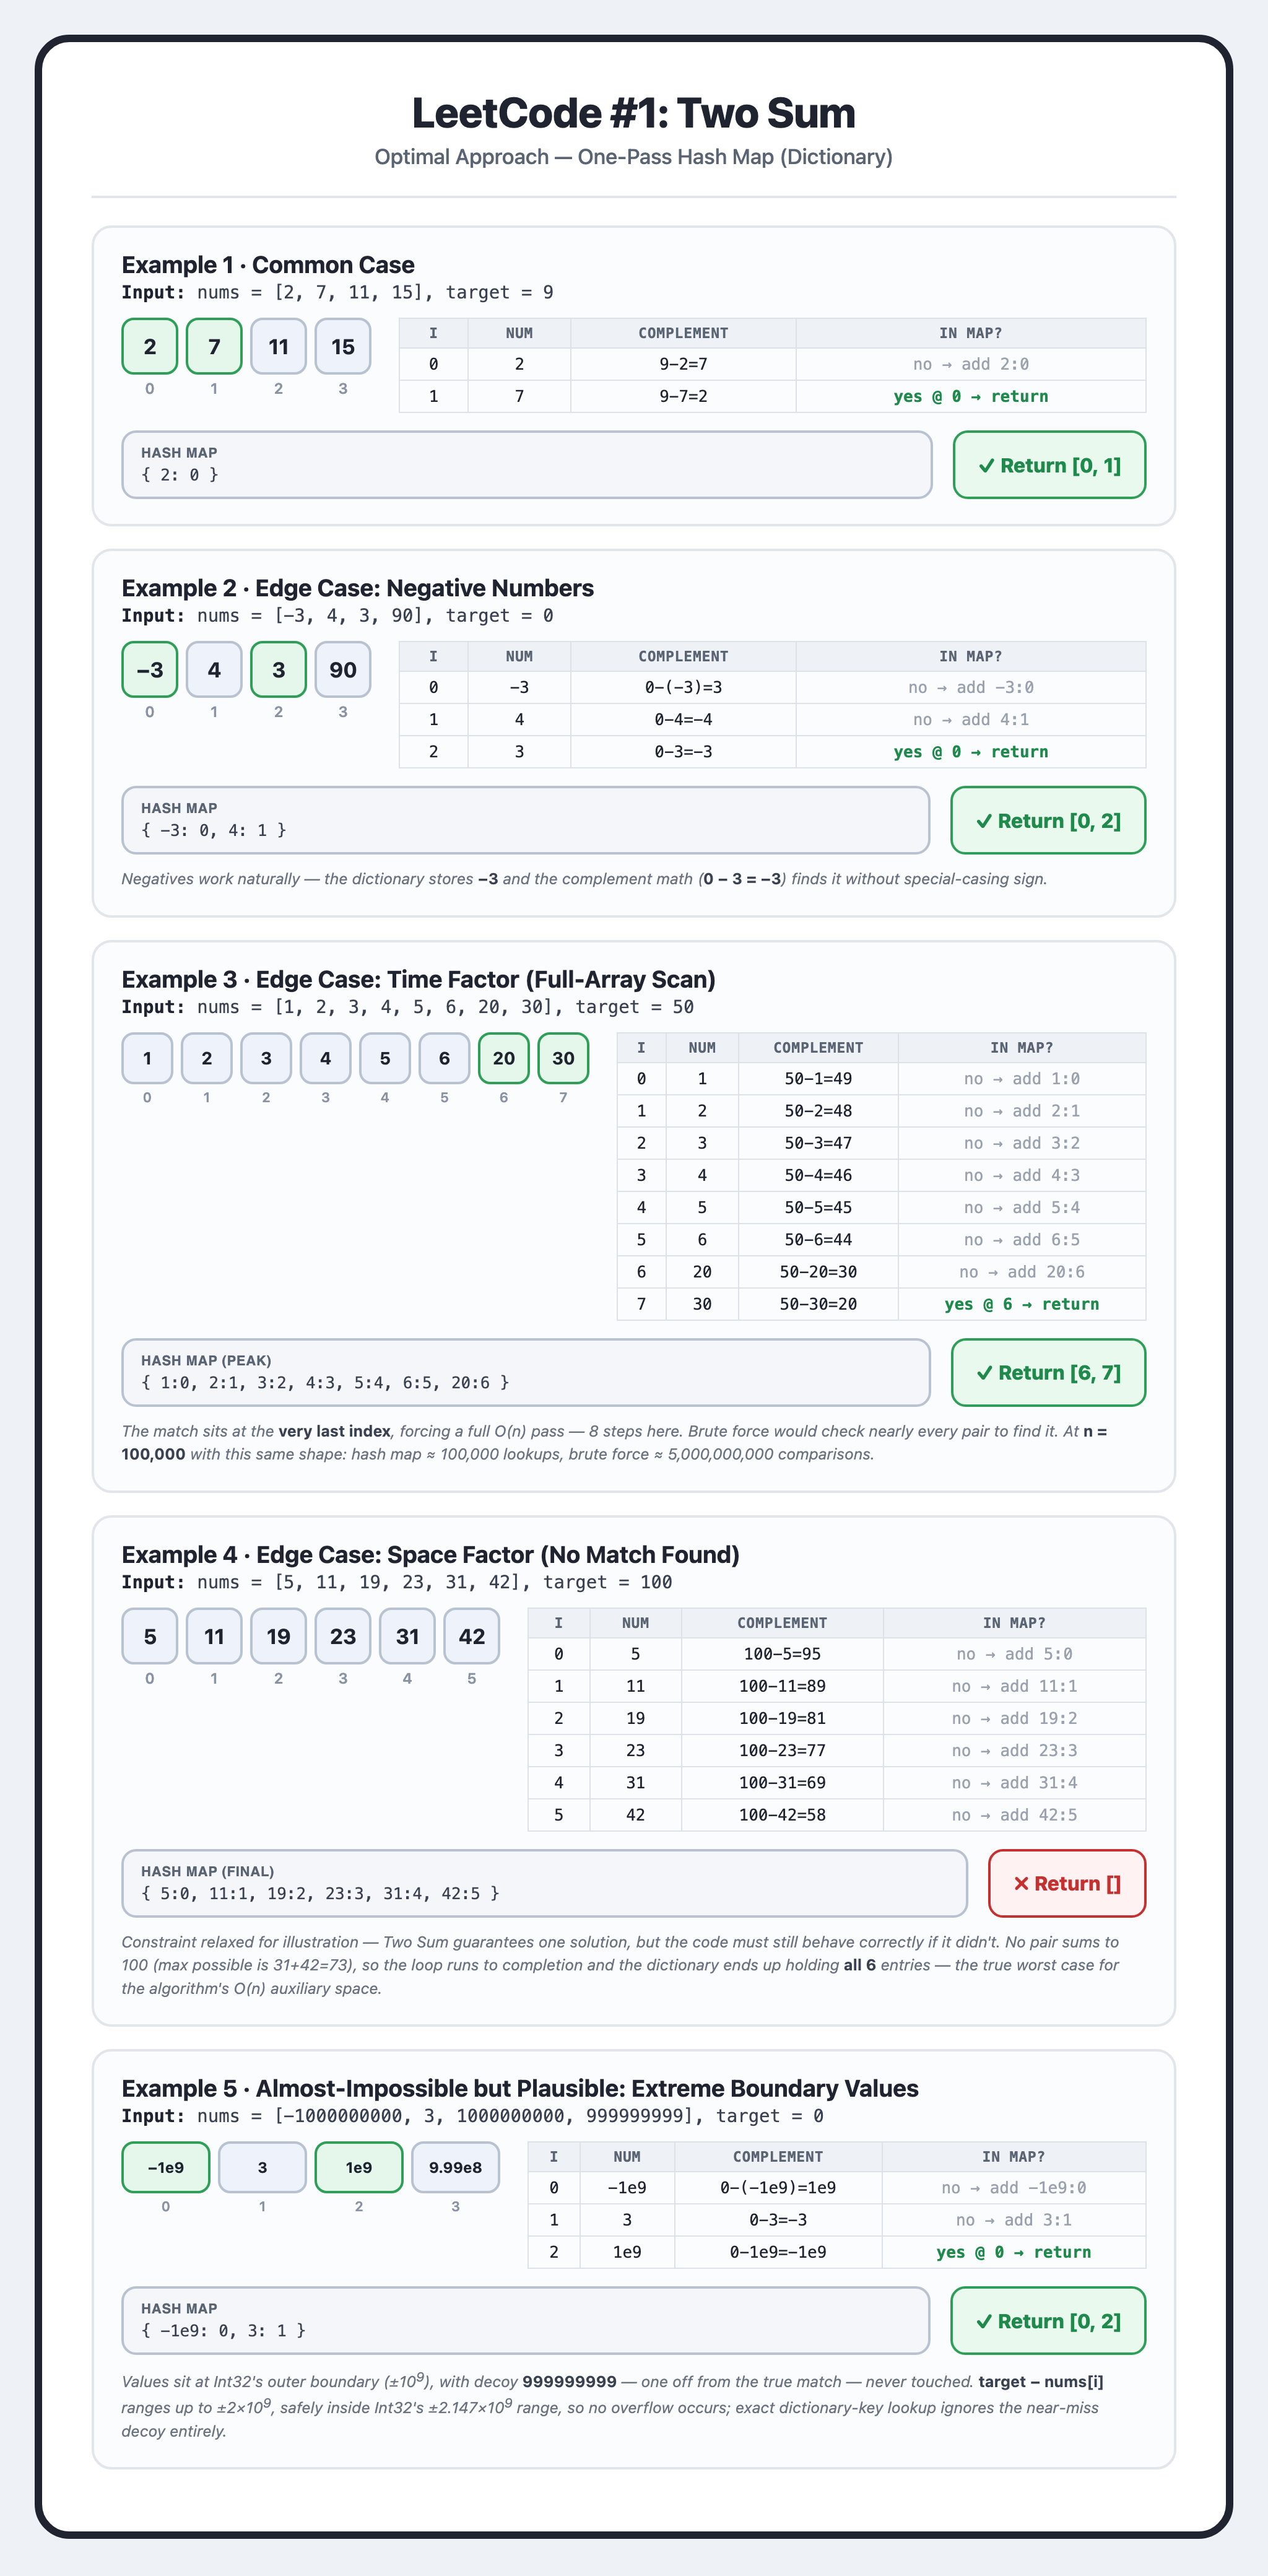